<a href="https://colab.research.google.com/github/sarra-mejbri/adult-income-analysis/blob/main/adult_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
df = pd.read_csv("adult.data", header=None, skipinitialspace=True)

df.head()


columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df.columns = columns

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# **Partie 1: Nettoyage de données**

**Gestion des doublons**


In [ ]:
print("Nombre de doublons:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Nombre de doublons après suppression:", df.duplicated().sum())

Nombre de doublons: 24
Nombre de doublons après suppression: 0


**Gestion des valeurs manquantes et visualisation de données**

Valeurs manquantes: age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     582
income               0
dtype: int64


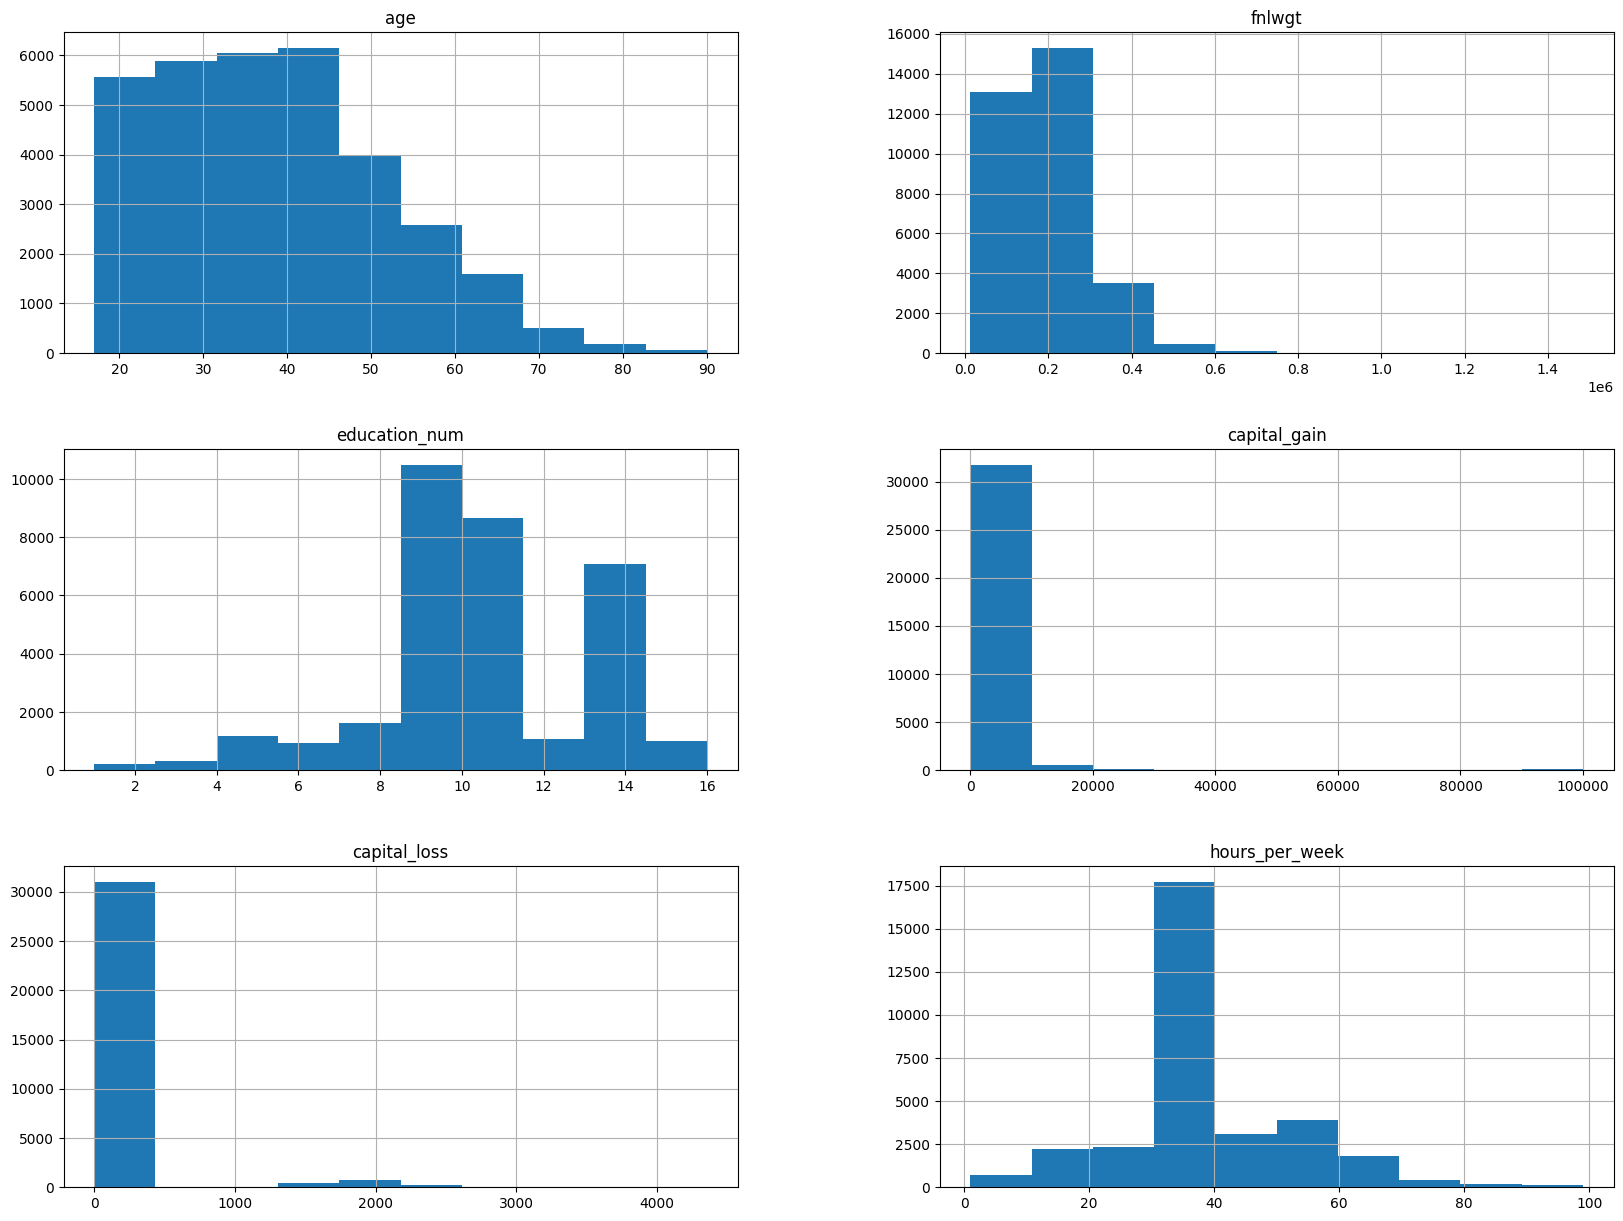

In [ ]:
df = df.replace('?', np.nan)

print("Valeurs manquantes:", df.isnull().sum())
df.hist(figsize=(20,15))
plt.show()

### **Partie 2: Transformation de données**

**Encodage de la variable cible income**

In [ ]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()
df['income'] = target_encoder.fit_transform(df['income'])
print(df['income'].value_counts())
# 0 = <=50K, 1 = >50K

income
0    24698
1     7839
Name: count, dtype: int64


**Encodage de education**

In [ ]:
# Pas besoin de LabelEncoder sur "education" — on utilise education_num directement
print(df[['education', 'education_num']].drop_duplicates().sort_values('education_num'))

        education  education_num
224     Preschool              1
160       1st-4th              2
56        5th-6th              3
15        7th-8th              4
6             9th              5
77           10th              6
3            11th              7
415          12th              8
2         HS-grad              9
10   Some-college             10
14      Assoc-voc             11
13     Assoc-acdm             12
0       Bachelors             13
5         Masters             14
52    Prof-school             15
20      Doctorate             16


**Normalisation**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
colonnes_a_normaliser = ['age', 'education_num']  # celles utiles à ton analyse
df_normalized = df.copy()
df_normalized[colonnes_a_normaliser] = scaler.fit_transform(df[colonnes_a_normaliser])

In [ ]:
df_normalized.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030390,State-gov,77516,Bachelors,1.134777,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,0.836973,Self-emp-not-inc,83311,Bachelors,1.134777,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,-0.042936,Private,215646,HS-grad,-0.420679,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,1.056950,Private,234721,11th,-1.198407,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,-0.776193,Private,338409,Bachelors,1.134777,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


## **Partie 3: Sélection des caractéristiques**

**Matrice de corrélation**

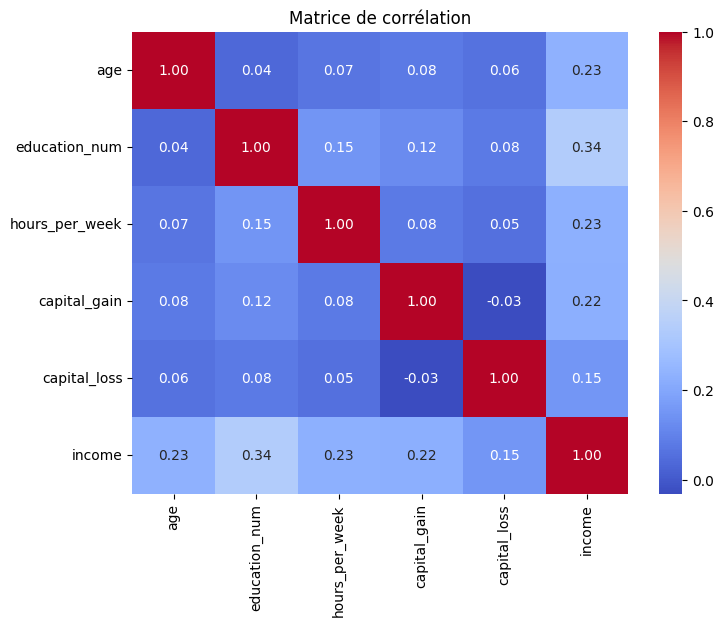

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# On sélectionne seulement les colonnes numériques utiles à ton analyse
colonnes_numeriques = ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss', 'income']

corr_matrix = df[colonnes_numeriques].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True)
plt.title('Matrice de corrélation')
plt.show()

**Sélectionner les caractéristiques**


In [ ]:
# Affichage des corrélations avec la cible
target = 'income'
if target in df_normalized.columns:
    print("\nCorrélations avec la cible (avant filtrage) :")
    print(corr_matrix[target].abs())

    # Sélection automatique des caractéristiques bien corrélées avec la cible (seuil global)
    correlation_threshold = 0.1
    target_corr = corr_matrix[target].abs()
    selected_features = target_corr[target_corr > correlation_threshold].index.tolist()
    if target in selected_features:
        selected_features.remove(target)
    print(f"\nSélection automatique (toutes variables |corr| > {correlation_threshold}) : {selected_features}")

    # Filtrage selon MON besoin métier spécifique : l'éducation
    mes_features = ['education_num']
    print(f"\nFeatures retenues pour mon analyse (besoin métier: éducation) : {mes_features}")

else:
    print(f"\nErreur : la cible '{target}' n'est pas dans le dataset.")
    exit()


Corrélations avec la cible (avant filtrage) :
age               0.234037
education_num     0.335272
hours_per_week    0.229658
capital_gain      0.223336
capital_loss      0.150501
income            1.000000
Name: income, dtype: float64

Sélection automatique (toutes variables |corr| > 0.1) : ['age', 'education_num', 'hours_per_week', 'capital_gain', 'capital_loss']

Features retenues pour mon analyse (besoin métier: éducation) : ['education_num']


**Créer un DataFrame avec les caractéristiques sélectionnées**

In [ ]:
df_selected = df[mes_features + [target]]
print(df_selected.head())

   education_num  income
0             13       0
1             13       0
2              9       0
3              7       0
4             13       0
